In [338]:
from statsmodels.tsa.stattools import adfuller, kpss, acf
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
import statsmodels.api as sm
from pylab import rcParams
import warnings

In [324]:
weather_df = pd.read_csv(r"C:\Users\USER\Desktop\weather_data_final_clean.csv")
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])

weather_df = weather_df.set_index("datetime").sort_index()

weather_df = weather_df.asfreq("D")
print(weather_df.isna().sum())

temp           0
tempmax        0
tempmin        0
humidity       0
dew            0
precip         0
precipprob     0
windspeed      0
pressure       0
cloudcover     0
solarenergy    0
uvindex        0
dtype: int64


In [325]:
split_date = '2025-08-01'
train = weather_df.loc[weather_df.index < split_date]
test = weather_df.loc[weather_df.index >= split_date]
print(f"Training Set: From {train.index.min().date()} To {train.index.max().date()} | Number of days: {len(train)}")
print(f"Test Set: From {test.index.min().date()} To {test.index.max().date()} | Number of days: {len(test)}")

Training Set: From 2019-01-01 To 2025-07-31 | Number of days: 2404
Test Set: From 2025-08-01 To 2026-08-05 | Number of days: 370


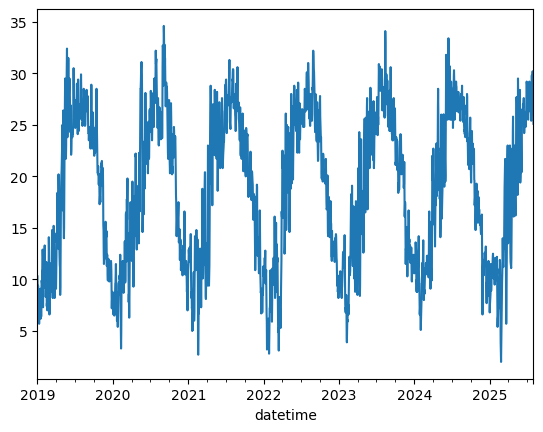

In [326]:
train["temp"].plot()
plt.show()

In [330]:
adf_result = adfuller(train["temp"])
print(adf_results)

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

# القرار الإحصائي
if adf_result[1] <= 0.05:
    print("\nConclusion: The series is STATIONARY (Reject H0)")
else:
    print("\nConclusion: The series is NON-STATIONARY (Fail to reject H0)")
#-------------------------------
# تطبيق الاختبار على بيانات الـ Train (مع حذف أي قيم مفقودة إن وجدت)
kpss_stat, p_value, lags, crit_bounds = kpss(train["temp"], regression='c')

print(f"KPSS Statistic: {kpss_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print("Critical Values:", crit_bounds)

# Decision Rule
if p_value < 0.05:
    print("Conclusion: Reject H0 -> The series is NON-STATIONARY")
else:
    print("Conclusion: Fail to reject H0 -> The series is STATIONARY")

(np.float64(-2.9386574942914616), np.float64(0.04103380627292413), 13, 2390, {'1%': np.float64(-3.4330890532791027), '5%': np.float64(-2.8627500747103762), '10%': np.float64(-2.5674141737714677)}, np.float64(9136.036249670466))
ADF Statistic: -2.9387
p-value: 0.0410
Critical Values:
   1%: -3.4331
   5%: -2.8628
   10%: -2.5674

Conclusion: The series is STATIONARY (Reject H0)
KPSS Statistic: 0.0701
p-value: 0.1000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Conclusion: Fail to reject H0 -> The series is STATIONARY


C:\Users\USER\AppData\Local\Temp\ipykernel_20832\3050284830.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, lags, crit_bounds = kpss(train["temp"], regression='c')


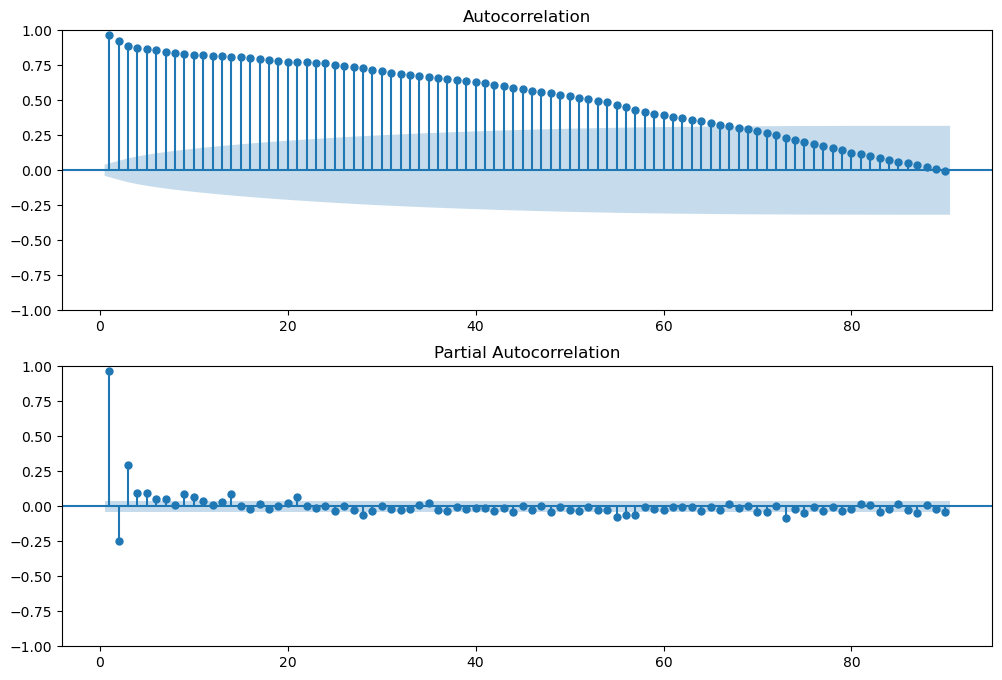

In [334]:
# Create figure
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
 
# Plot the ACF of savings on ax1
plot_acf(train["temp"], lags = 90, zero = False, ax = ax1)

# Plot the PACF of savings on ax2
plot_pacf(train["temp"], lags = 90, zero = False, ax = ax2)

plt.show()

In [341]:
order_aic_bic = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for p in range(5):
        for q in range(5):
            try:
                model = ARIMA(train["temp"], order = (p, 0, q))
                results = model.fit()
                order_aic_bic.append((p, q, results.aic, results.bic))
            except:
                order_aic_bic.append((p, q, None, None))
order_df = pd.DataFrame(order_aic_bic, columns = ['p', 'q', 'aic', 'bic'])
print(order_df.sort_values('aic'))

    p  q           aic           bic
9   1  4   9258.724405   9299.218630
19  3  4   9258.940827   9311.004830
21  4  1   9259.041879   9299.536104
14  2  4   9259.842840   9306.121955
17  3  2   9260.308606   9300.802831
24  4  4   9260.326788   9318.175681
22  4  2   9260.676575   9306.955689
13  2  3   9260.892112   9301.386337
18  3  3   9261.535777   9307.814892
23  4  3   9263.361749   9315.425753
12  2  2   9277.933851   9312.643187
16  3  1   9289.922868   9324.632204
8   1  3   9302.475290   9337.184626
20  4  0   9326.534584   9361.243919
15  3  0   9346.581795   9375.506241
7   1  2   9424.169346   9453.093792
11  2  1   9452.237488   9481.161935
6   1  1   9466.106300   9489.245857
10  2  0   9575.751892   9598.891449
5   1  0   9726.726922   9744.081589
4   0  4  10625.048989  10659.758325
3   0  3  11003.717870  11032.642317
2   0  2  11917.858372  11940.997929
1   0  1  13566.458735  13583.813403
0   0  0  16385.228212  16396.797991


--- Manual ARIMA Summary ---
                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 2404
Model:                 ARIMA(1, 0, 4)   Log Likelihood               -4622.362
Date:                Sat, 08 Aug 2026   AIC                           9258.724
Time:                        16:33:53   BIC                           9299.219
Sample:                    01-01-2019   HQIC                          9273.455
                         - 07-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.7335      2.534      7.392      0.000      13.766      23.701
ar.L1          0.9932      0.003    332.791      0.000       0.987       0.999
ma.L1          0.2285  

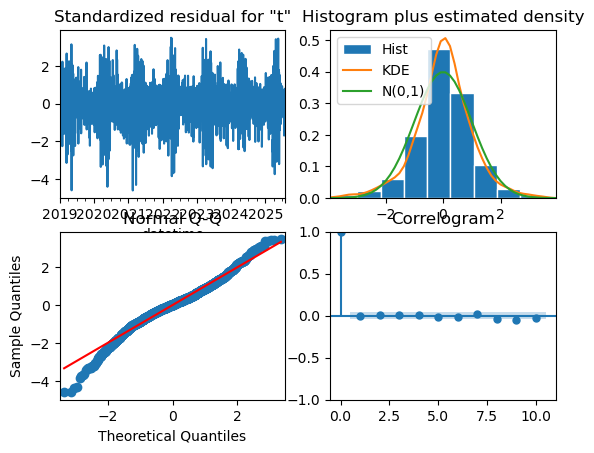

--- Manual ARIMA Forecast ---
2025-08-01    24.825270
2025-08-02    25.639877
2025-08-03    26.263138
2025-08-04    26.546241
2025-08-05    26.492888
                ...    
2026-07-27    19.410207
2026-07-28    19.405586
2026-07-29    19.400997
2026-07-30    19.396439
2026-07-31    19.391912
Freq: D, Name: predicted_mean, Length: 365, dtype: float64
--- Auto ARIMA Summary ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2404
Model:               SARIMAX(4, 0, 1)   Log Likelihood               -4622.521
Date:                Sat, 08 Aug 2026   AIC                           9259.042
Time:                        16:34:27   BIC                           9299.536
Sample:                    01-01-2019   HQIC                          9273.772
                         - 07-31-2025                                         
Covariance Type:                  opg                              

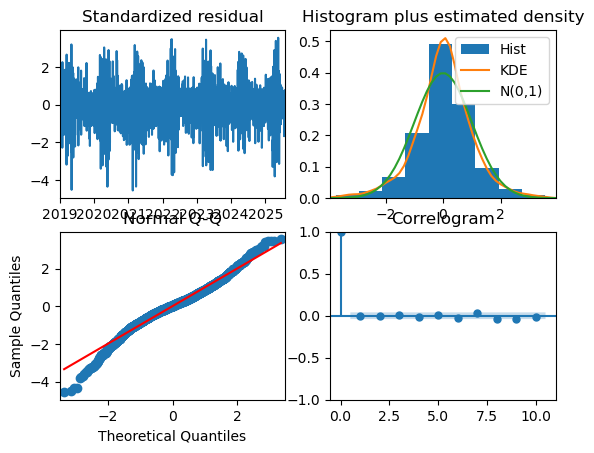

AttributeError: 'ARIMA' object has no attribute 'get_forecast'

In [346]:
# 1. الموديل اليدوي (Manual ARIMA)
model_arma = ARIMA(train["temp"], order=(1, 0, 4))
fit_model_arma = model_arma.fit()
print("--- Manual ARIMA Summary ---")
print(fit_model_arma.summary())
fit_model_arma.plot_diagnostics()
plt.show()

values_arma = fit_model_arma.get_forecast(steps=365).predicted_mean
print("--- Manual ARIMA Forecast ---")
print(values_arma)

# ----------------------------------

# 2. الموديل التلقائي (Auto ARIMA)
model_arma_auto = pm.auto_arima(
    train["temp"],
    information_criterion="aic",
    error_action="ignore",
    stepwise=True,
)

print("--- Auto ARIMA Summary ---")
print(model_arma_auto.summary())
model_arma_auto.plot_diagnostics()
plt.show()

# لإظهار التوقعات المستقبلية لـ auto_arima:
values_arma_auto = model_arma_auto.get_forecast(steps=365).predicated_mean
print("--- Auto ARIMA Forecast ---")
print(values_arma_auto)

In [62]:
train.describe()

,temp,tempmax,tempmin,humidity,dew,precip,precipprob,windspeed,pressure,cloudcover,solarenergy,uvindex
count,2404.000000,2404.000000,2404.000000,2404.000000,2404.000000,2404.000000,2404.000000,2404.000000,2404.000000,2404.000000,2404.000000,2404.000000
mean,18.760275,24.502829,13.530782,54.167055,7.828869,1.208931,17.013311,20.469093,1014.922837,22.923336,19.725790,7.707987
std,7.303451,8.397906,6.325282,17.455995,4.744967,4.715167,37.582787,7.241972,4.808927,19.607427,7.178015,2.081867
min,2.000000,5.000000,-1.800000,15.100000,-10.800000,0.000000,0.000000,6.400000,1001.500000,0.000000,0.000000,0.000000
25%,11.800000,17.000000,7.700000,39.975000,4.500000,0.000000,0.000000,15.700000,1011.200000,7.000000,13.200000,6.000000
50%,19.650000,25.800000,14.000000,54.550000,7.600000,0.000000,0.000000,20.100000,1014.600000,17.450000,20.100000,8.000000
75%,25.300000,31.900000,19.100000,66.900000,11.500000,0.000000,0.000000,24.100000,1018.300000,35.200000,26.800000,10.000000
max,34.600000,42.600000,28.900000,96.000000,20.800000,70.083000,100.000000,87.500000,1029.400000,94.800000,30.200000,10.000000


In [79]:
# 1. تحديد حد القيمة المتطرفة للأمطار (مثلاً أعلى من 30 ملم)
high_precip_limit = 30.0

# 2. فلترة الأيام التي بها أمطار عالية ولكن الغيوم صافية أو شبه صافية (أقل من 20%)
impossible_outliers = train[(train['precip'] > high_precip_limit) & (train['cloudcover'] < 20)]

# 3. طباعة النتائج لرؤية التواريخ أو الأسطر الخاطئة
print(f"عدد القيم المتطرفة غير الطبيعية (الخاطئة): {len(impossible_outliers)}")
print(impossible_outliers[['precip', 'cloudcover']])


عدد القيم المتطرفة غير الطبيعية (الخاطئة): 1
            precip  cloudcover
datetime                      
2020-12-25  53.722         5.1


In [92]:
train.loc['2020-12-25', 'precip'] = np.nan
train = train.assign(precip = train['precip'].interpolate(method='linear', limit_direction='both'))

                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 2404
Model:                 ARIMA(1, 0, 4)   Log Likelihood               -4622.362
Date:                Sat, 08 Aug 2026   AIC                           9258.724
Time:                        08:09:24   BIC                           9299.219
Sample:                    01-01-2019   HQIC                          9273.455
                         - 07-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.7335      2.534      7.392      0.000      13.766      23.701
ar.L1          0.9932      0.003    332.791      0.000       0.987       0.999
ma.L1          0.2285      0.017     13.839      0.0

In [307]:
arma_residuals = fit_model_arma.resid
mae = np.mean(np.abs(arma_residuals))
print(mae)

1.215642884115733


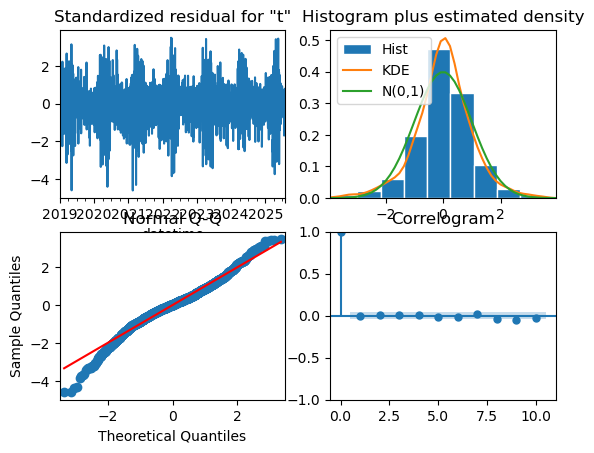

In [238]:
fit_model_arma.plot_diagnostics()
plt.show()

In [301]:
exog_cols = ["humidity", "tempmax", "dew", "tempmin", "precip", "cloudcover", "precipprob"]
model_armax = ARIMA(train["temp"], order = (1, 0, 4), exog = train[exog_cols])
fit_model_armax = model_armax.fit()
print(fit_model_armax.summary())
future_exog = test[exog_cols].iloc[:365]
values_armax = fit_model_armax.get_forecast(steps = 365, exog = future_exog).predicted_mean
print(values_armax)

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 2404
Model:                 ARIMA(1, 0, 4)   Log Likelihood               -1179.018
Date:                Sat, 08 Aug 2026   AIC                           2386.035
Time:                        08:08:48   BIC                           2467.024
Sample:                    01-01-2019   HQIC                          2415.496
                         - 07-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9882      0.195     20.454      0.000       3.606       4.370
humidity      -0.0549      0.002    -23.965      0.000      -0.059      -0.050
tempmax        0.4555      0.005     86.823      0.0

In [302]:
armax_residuals = fit_model_armax.resid
mae = np.mean(np.abs(armax_residuals))
print(mae)

0.30489185900017707


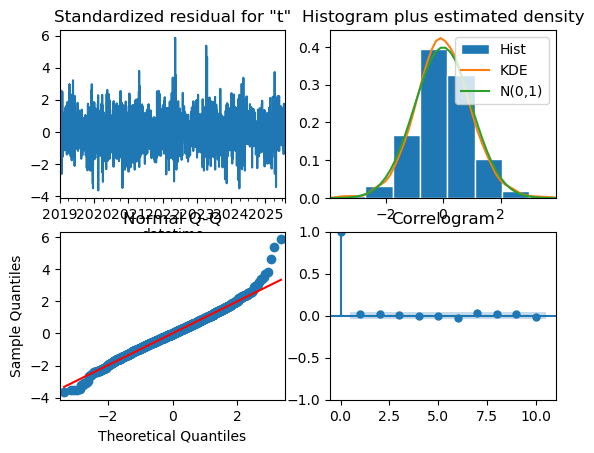

In [237]:
fit_model_armax.plot_diagnostics()
plt.show()

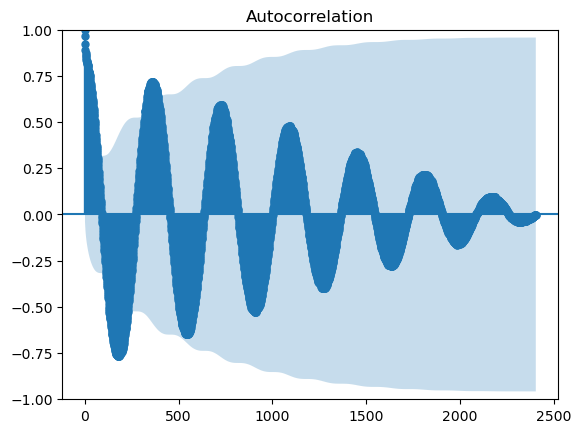

Detected Seasonal Period: 356 days


In [241]:
plot_acf(train["temp"], lags = len(train) - 1)
plt.show()
# حساب قيمة الـ ACF لـ 400 lag
acf_values = acf(train["temp"], nlags=400)

# البحث عن القمة بعد أول 30 يوم لنتجنب الـ lag القريب جداً
peak_lag = np.argmax(acf_values[30:]) + 30

print(f"Detected Seasonal Period: {peak_lag} days")

In [298]:
print(results_pm)

 ARIMA(4,0,1)(0,0,0)[0] intercept


In [322]:
model_sarima = SARIMAX(train['temp'], order = (1, 0, 4), seasonal_order = (1, 1, 0,365))
fit_model_sarima = model_sarima.fit()
print(fit_model_sarima.summary())
values_sarima = fit_model_sarima.get_forecast(steps = 365).predicted_mean
print(values_sarima)
sarima_residuals = fit_model_sarima.resid
mae = np.mean(np.abs(sarima_residuals))
print(mae)

KeyboardInterrupt: 

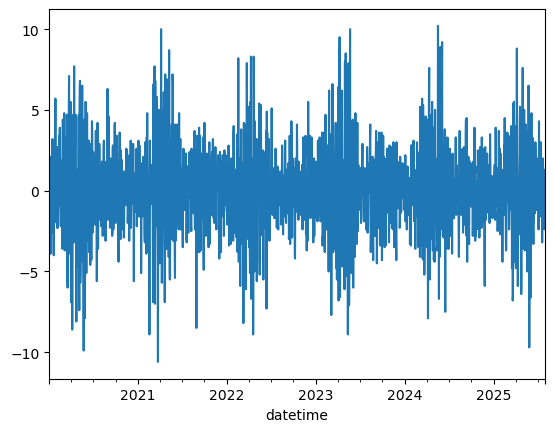

In [271]:
train_diff_s = train.diff().diff(365).dropna()
train_diff_s["temp"].plot()
plt.show()

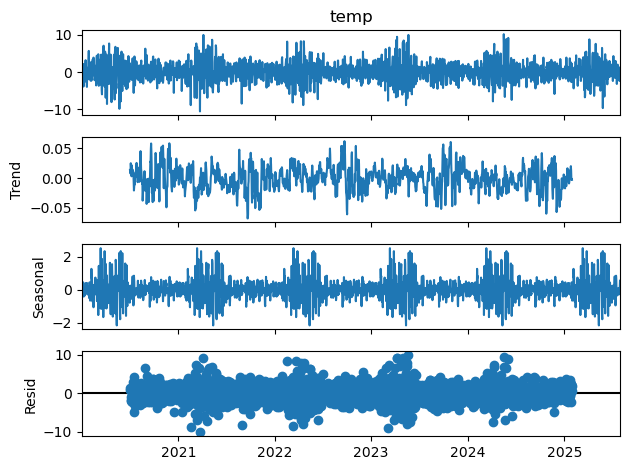

In [272]:
decomp_results_s = seasonal_decompose(train_diff_s["temp"], model="additive", period=365)
decomp_results_s.plot()
plt.show()

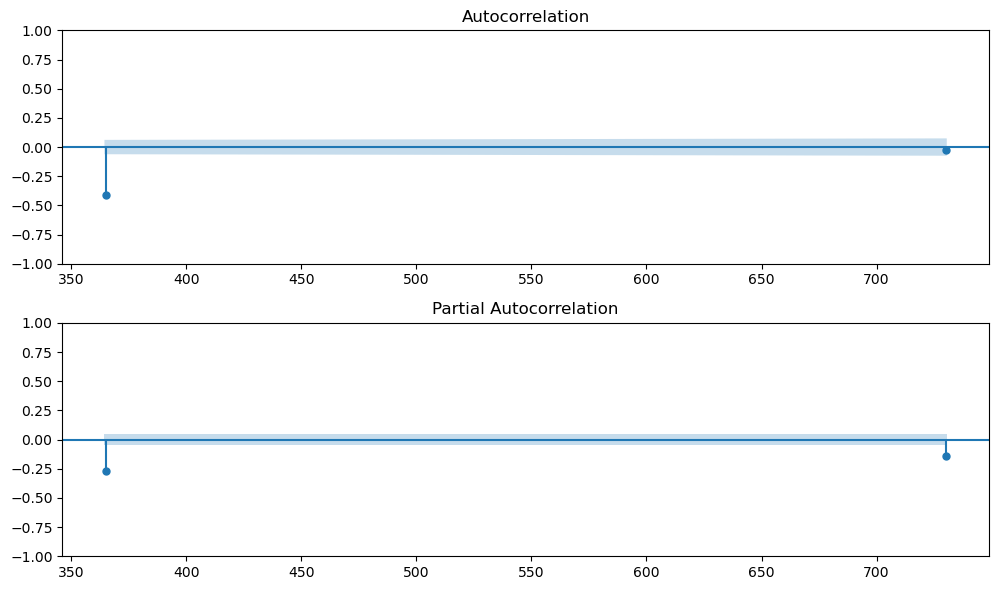

In [285]:
# قائمة بمضاعفات السنة لـ 3 سنوات
seasonal_lags = [365, 730]

# رسم ACF و PACF للمضاعفات فقط
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

plot_acf(train_diff_s['temp'], lags=seasonal_lags, ax=ax1)
plot_pacf(train_diff_s['temp'], lags=seasonal_lags, ax=ax2)

plt.tight_layout()
plt.show()

In [316]:
results = results.resid
mae = np.mean(np.abs(results))
print(mae)

1.2102430688288084


In [320]:
t = np.arange(len(train))

for k in range(1, 4):
    train[f'sin_year_{k}'] = np.sin(2 * np.pi * k * t / 365.25)
    train[f'cos_year_{k}'] = np.cos(2 * np.pi * k * t / 365.25)

model = SARIMAX(
    train["temp"],
    exog=train[exog_cols + [
        "sin_year_1", "cos_year_1",
        "sin_year_2", "cos_year_2",
        "sin_year_3", "cos_year_3"
    ]],
    order=(4, 0, 1),
    seasonal_order=(0, 0, 0, 0)
    
)
resu = model.fit()
resu = resu.resid
mae = np.mean(np.abs(resu))

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [321]:
print(mae)

0.3198460245585692
